In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap

Dataset: <br>
League - All <br>
Year(s) - 2021-25 <br>

In [2]:
# --- 1. DATA PREPARATION (Condensed for clarity) ---
df = pd.read_csv('../data/v0/Final_DataSet_All.csv')

filtered_ft = df.loc[df['Time'] == 'FT'].copy()
conditions = [(filtered_ft['Home_Score'] > filtered_ft['Away_Score']),
              (filtered_ft['Away_Score'] > filtered_ft['Home_Score']),
              (filtered_ft['Home_Score'] == filtered_ft['Away_Score'])]
choices = ['Home_Win', 'Away_Win', 'Draw']
filtered_ft['Match_Outcomes'] = np.select(conditions, choices, default='Unknown')
df['Match_Outcomes'] = df['Game_ID'].map(dict(zip(filtered_ft['Game_ID'], filtered_ft['Match_Outcomes'])))

df_mod = df[(df['Time'] != 'FT') & (df['Matchweek'] != 'Cup')].copy()
df_mod['Time'] = df_mod['Time'].apply(eval)
df_mod['Score_Diff'] = df_mod['Home_Score'] - df_mod['Away_Score']
df_mod['Home_Score_Log'] = np.log1p(df_mod['Home_Score'])
df_mod['Away_Score_Log'] = np.log1p(df_mod['Away_Score'])

features = ['Time', 'Score_Diff', 'Home_Score_Log', 'Away_Score_Log', 
            'Home_Red_Count', 'Away_Red_Count', 'Home_Off_Sub_Count', 
            'Away_Off_Sub_Count']
X = df_mod[features].fillna(0)
y_true = df_mod['Match_Outcomes']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

--- Stage 1: Unsupervised UMAP (Baseline) ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


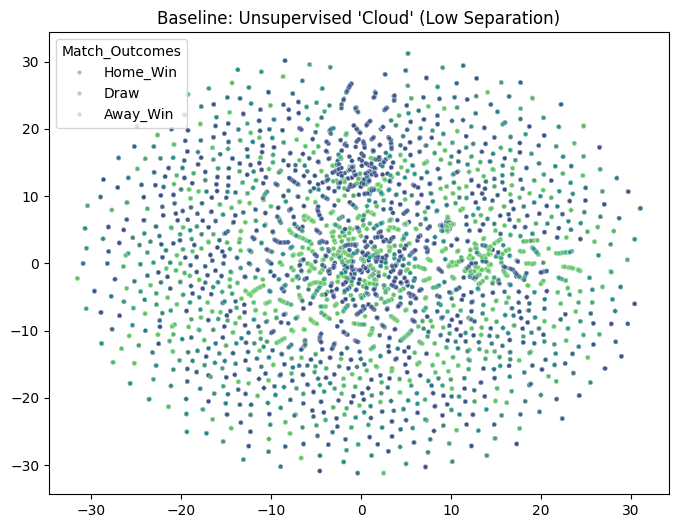


REASONING FOR NEXT STEP:
The baseline shows outcomes are heavily intermingled. This happens because match
states like '1-0 at 60 mins' can lead to any outcome. We will now move to
SUPERVISED UMAP to force the model to find the specific feature combinations
that define a 'Draw' versus a 'Win'.


In [3]:
# STAGE 1: BASELINE (The "Cloud" Result)
# =================================================================
print("--- Stage 1: Unsupervised UMAP (Baseline) ---")
# This is what produced the v1 scatter plot
reducer_base = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
X_umap_base = reducer_base.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_umap_base[:, 0], y=X_umap_base[:, 1], hue=y_true, s=10, alpha=0.4, palette='viridis')
plt.title("Baseline: Unsupervised 'Cloud' (Low Separation)")
plt.show()

print("\nREASONING FOR NEXT STEP:")
print("The baseline shows outcomes are heavily intermingled. This happens because match")
print("states like '1-0 at 60 mins' can lead to any outcome. We will now move to")
print("SUPERVISED UMAP to force the model to find the specific feature combinations")
print("that define a 'Draw' versus a 'Win'.")


--- Stage 2: Supervised UMAP + HDBSCAN ---


C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
C:\Users\matth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to rand

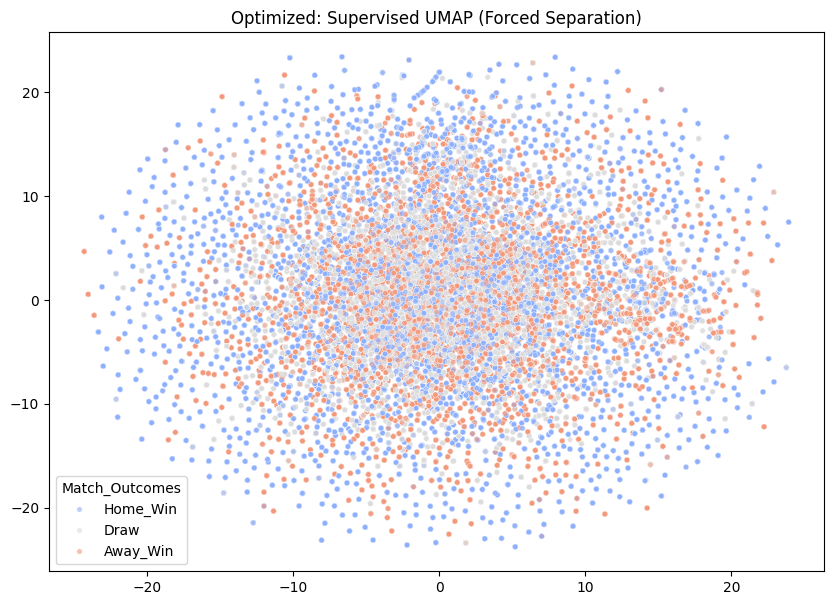


WHAT CHANGED:
By using Supervised UMAP, we told the algorithm: 'Look at the features, but prioritize
the versions of those features that lead to different outcomes.' This creates clear
islands. We also reduced min_dist to make the clusters tighter for HDBSCAN.


In [4]:
# STAGE 2: OPTIMIZED (Supervised UMAP + HDBSCAN)
# =================================================================
print("\n--- Stage 2: Supervised UMAP + HDBSCAN ---")

# Supervised UMAP: We pass 'y' into the fit to help it learn the manifold
reducer_opt = umap.UMAP(
    n_neighbors=15, 
    min_dist=0.01, 
    n_components=2, 
    target_weight=0.5, # Balance between feature structure and label separation
    random_state=42
)
X_umap_opt = reducer_opt.fit_transform(X_scaled, y=pd.factorize(y_true)[0])

# HDBSCAN on the "forced" islands
clusterer_opt = hdbscan.HDBSCAN(
    min_cluster_size=40,
    prediction_data=True,
    cluster_selection_method='eom'
)
labels_opt = clusterer_opt.fit_predict(X_umap_opt)

# Visualizing the New Islands
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_umap_opt[:, 0], y=X_umap_opt[:, 1], hue=y_true, s=15, palette='coolwarm', alpha=0.6)
plt.title("Optimized: Supervised UMAP (Forced Separation)")
plt.show()

print("\nWHAT CHANGED:")
print("By using Supervised UMAP, we told the algorithm: 'Look at the features, but prioritize")
print("the versions of those features that lead to different outcomes.' This creates clear")
print("islands. We also reduced min_dist to make the clusters tighter for HDBSCAN.")


--- Stage 3: Feature Profiling ---
Cluster Purity (Top 5 Draw-Heavy Clusters):
Outcome  Away_Win  Draw  Home_Win
Cluster                          
558           0.0   1.0       0.0
500           0.0   1.0       0.0
333           0.0   1.0       0.0
772           0.0   1.0       0.0
653           0.0   1.0       0.0


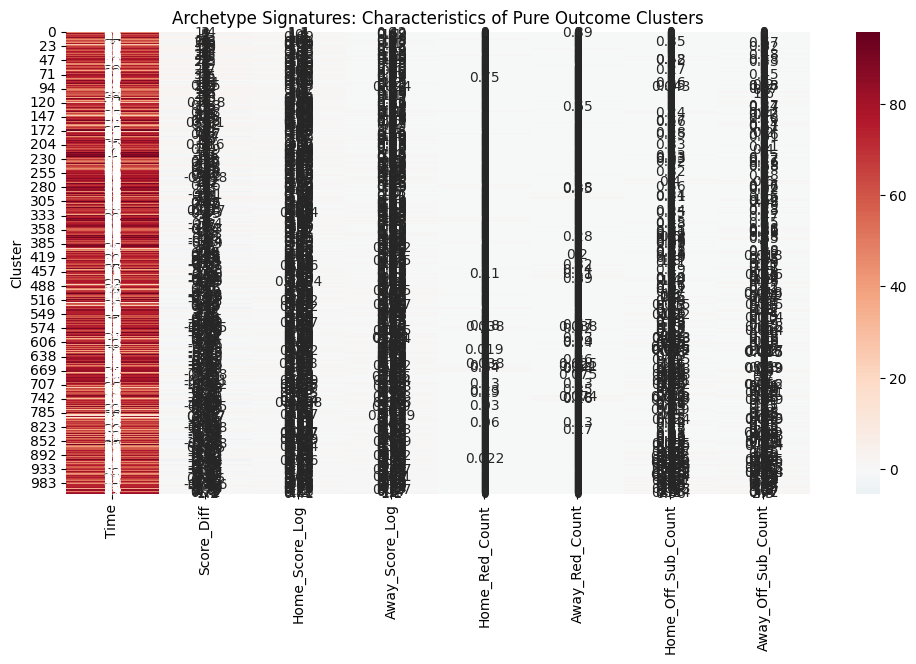

In [6]:
# --- Stage 3: Feature Profiling (Fixed) ---
print("\n--- Stage 3: Feature Profiling ---")

analysis_df = X.copy()
analysis_df['Cluster'] = labels_opt
analysis_df['Outcome'] = y_true.values # Ensure indices align

# 1. Calculate Purity: Which outcomes dominate which clusters?
cluster_purity = pd.crosstab(analysis_df['Cluster'], analysis_df['Outcome'], normalize='index')
print("Cluster Purity (Top 5 Draw-Heavy Clusters):")
print(cluster_purity.sort_values(by='Draw', ascending=False).head())

# 2. Identify 'Pure' Clusters (where one outcome is > 60% of the total)
pure_cluster_ids = cluster_purity.index[cluster_purity.max(axis=1) > 0.6]

# 3. Calculate means ONLY for numeric columns to avoid the TypeError
# We filter for pure clusters and then group by Cluster
cluster_stats = analysis_df[analysis_df['Cluster'].isin(pure_cluster_ids)].groupby('Cluster').mean(numeric_only=True)

# 4. Visualize the Heatmap
if not cluster_stats.empty:
    plt.figure(figsize=(12, 6))
    # Standardize the stats for the heatmap so Time and Red Cards use the same scale
    sns.heatmap(cluster_stats, annot=True, cmap='RdBu_r', center=0)
    plt.title("Archetype Signatures: Characteristics of Pure Outcome Clusters")
    plt.show()
else:
    print("No 'pure' clusters found with the current thresholds. Try lowering the 0.6 purity limit.")
